In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#

In [2]:
df = pd.read_csv("/content/all.csv")

In [15]:
df.head()

,Unnamed: 0,State,District,Persons,Males,Females,Growth..1991...2001.,Rural,Urban,Scheduled.Caste.population,...,Medical.facility,Primary.Health.Centre,Primary.Health.Sub.Centre,Post..telegraph.and.telephone.facility,Bus.services,Paved.approach.road,Mud.approach.road,Permanent.House,Semi.permanent.House,Temporary.House
0,1,AN,"District Andamans (01), Andaman & Nicobar Isla...",314084,170319,143765,30.14,-,116198,-,...,102,16,78,161.0,187,201,243,28.7,39.1,32.0
1,2,AN,"District Nicobars (02), Andaman & Nicobar Isla...",42068,22653,19415,7.19,-,-,-,...,38,4,31,36.0,49,51,111,28.0,33.3,38.7
2,3,Andhra,"District Adilabad (01), Andhra Pradesh (28)",2488003,1250958,1237045,19.06,-,NaN,NaN,...,976,61,432,558.0,814,979,544,53.0,39.9,7.0
3,4,Andhra,"District Nizamabad (02), Andhra Pradesh (28)",2345685,1162905,1182780,14.98,-,NaN,NaN,...,614,50,330,602.0,746,760,82,52.8,37.6,9.6
4,5,Andhra,"District Karimnagar (03), Andhra Pradesh (28)",3491822,1747968,1743854,14.47,-,NaN,NaN,...,863,70,475,795.0,912,823,218,55.8,36.4,7.8


In [16]:
df.shape

(590, 82)

In [14]:
df.isnull().sum()

,0
Unnamed: 0,0
State,0
District,0
Persons,0
Males,0
...,...
Paved.approach.road,0
Mud.approach.road,0
Permanent.House,0
Semi.permanent.House,0


In [10]:
df['Paved.approach.road'] = df['Paved.approach.road'].fillna(df['Paved.approach.road'].mode()[0])

In [12]:
df['Mud.approach.road'] = df['Mud.approach.road'].fillna(df['Mud.approach.road'].mode()[0])

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('all.csv')

print("="*80)
print("INDIAN CENSUS DATA - PCA ANALYSIS")
print("="*80)

# Display basic info
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Columns: {len(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

INDIAN CENSUS DATA - PCA ANALYSIS

Dataset Shape: (590, 82)
Number of Columns: 82

First 5 rows:
   Unnamed: 0   State                                           District  \
0           1      AN  District Andamans (01), Andaman & Nicobar Isla...   
1           2      AN  District Nicobars (02), Andaman & Nicobar Isla...   
2           3  Andhra        District Adilabad (01), Andhra Pradesh (28)   
3           4  Andhra       District Nizamabad (02), Andhra Pradesh (28)   
4           5  Andhra      District Karimnagar (03), Andhra Pradesh (28)   

   Persons    Males  Females  Growth..1991...2001. Rural   Urban  \
0   314084   170319   143765                 30.14     -  116198   
1    42068    22653    19415                  7.19     -       -   
2  2488003  1250958  1237045                 19.06     -     NaN   
3  2345685  1162905  1182780                 14.98     -     NaN   
4  3491822  1747968  1743854                 14.47     -     NaN   

  Scheduled.Caste.population  ... Med

In [18]:
# View column names
print("\nColumn Names:")
print(df.columns.tolist())

# Check data types and missing values
print("\nData Types and Missing Values:")
print(df.dtypes.value_counts())
print(f"\nMissing values per column:\n{df.isnull().sum().sort_values(ascending=False).head(20)}")

# Select numeric columns for PCA
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns ({len(numeric_columns)}):")
print(numeric_columns[:20])  # Show first 20

# Remove identifier columns
exclude_cols = ['Unnamed: 0']  # Index column
numeric_columns = [col for col in numeric_columns if col not in exclude_cols]

print(f"\nNumeric columns after removing identifiers: {len(numeric_columns)}")


Column Names:
['Unnamed: 0', 'State', 'District', 'Persons', 'Males', 'Females', 'Growth..1991...2001.', 'Rural', 'Urban', 'Scheduled.Caste.population', 'Percentage...SC.to.total', 'Number.of.households', 'Household.size..per.household.', 'Sex.ratio..females.per.1000.males.', 'Sex.ratio..0.6.years.', 'Scheduled.Tribe.population', 'Percentage.to.total.population..ST.', 'Persons..literate', 'Males..Literate', 'Females..Literate', 'Persons..literacy.rate', 'Males..Literatacy.Rate', 'Females..Literacy.Rate', 'Total.Educated', 'Data.without.level', 'Below.Primary', 'Primary', 'Middle', 'Matric.Higher.Secondary.Diploma', 'Graduate.and.Above', 'X0...4.years', 'X5...14.years', 'X15...59.years', 'X60.years.and.above..Incl..A.N.S..', 'Total.workers', 'Main.workers', 'Marginal.workers', 'Non.workers', 'SC.1.Name', 'SC.1.Population', 'SC.2.Name', 'SC.2.Population', 'SC.3.Name', 'SC.3.Population', 'Religeon.1.Name', 'Religeon.1.Population', 'Religeon.2.Name', 'Religeon.2.Population', 'Religeon.3.N

In [19]:
# Select features for PCA (drop columns with too many missing values)
print("\n" + "="*60)
print("DATA PREPROCESSING")
print("="*60)

# Check missing value percentages
missing_percent = df[numeric_columns].isnull().sum() / len(df) * 100
missing_percent = missing_percent.sort_values(ascending=False)

print("\nColumns with missing values:")
print(missing_percent[missing_percent > 0].head(10))

# Drop columns with > 30% missing values
threshold = 30
cols_to_drop = missing_percent[missing_percent > threshold].index.tolist()
print(f"\nDropping columns with >{threshold}% missing values: {len(cols_to_drop)} columns")
print(cols_to_drop[:10] if cols_to_drop else "None")

# Keep columns for PCA
pca_features = [col for col in numeric_columns if col not in cols_to_drop]

# Drop columns with zero variance
variance = df[pca_features].var()
zero_var_cols = variance[variance == 0].index.tolist()
pca_features = [col for col in pca_features if col not in zero_var_cols]

print(f"\nFeatures for PCA: {len(pca_features)}")
print(f"Sample features: {pca_features[:15]}")

# Prepare data for PCA
X = df[pca_features].copy()

# Handle remaining missing values with median imputation
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFinal dataset shape for PCA: {X_scaled.shape}")
print(f"Number of districts/rows: {X_scaled.shape[0]}")
print(f"Number of features: {X_scaled.shape[1]}")


DATA PREPROCESSING

Columns with missing values:
Imp.Town.3.Population         18.305085
Imp.Town.2.Population         10.847458
Imp.Town.1.Population          2.372881
SC.2.Population                2.203390
SC.3.Population                2.203390
SC.1.Population                2.203390
Electricity..Power.Supply.     2.033898
Total.Inhabited.Villages       2.033898
Primary.school                 2.033898
Safe.Drinking.water            2.033898
dtype: float64

Dropping columns with >30% missing values: 0 columns
None

Features for PCA: 47
Sample features: ['Persons', 'Males', 'Females', 'Growth..1991...2001.', 'Number.of.households', 'Household.size..per.household.', 'Sex.ratio..females.per.1000.males.', 'Sex.ratio..0.6.years.', 'Persons..literate', 'Males..Literate', 'Females..Literate', 'Persons..literacy.rate', 'Males..Literatacy.Rate', 'Females..Literacy.Rate', 'Total.Educated']

Final dataset shape for PCA: (590, 47)
Number of districts/rows: 590
Number of features: 47



PCA ANALYSIS

Explained Variance by Components:
PC1: 51.70% (Cumulative: 51.70%)
PC2: 12.37% (Cumulative: 64.06%)
PC3: 6.89% (Cumulative: 70.95%)
PC4: 4.87% (Cumulative: 75.83%)
PC5: 3.21% (Cumulative: 79.04%)
PC6: 2.70% (Cumulative: 81.73%)
PC7: 2.23% (Cumulative: 83.96%)
PC8: 2.07% (Cumulative: 86.04%)
PC9: 1.83% (Cumulative: 87.86%)
PC10: 1.53% (Cumulative: 89.39%)

Components needed for 90% variance: 11
Components needed for 95% variance: 15


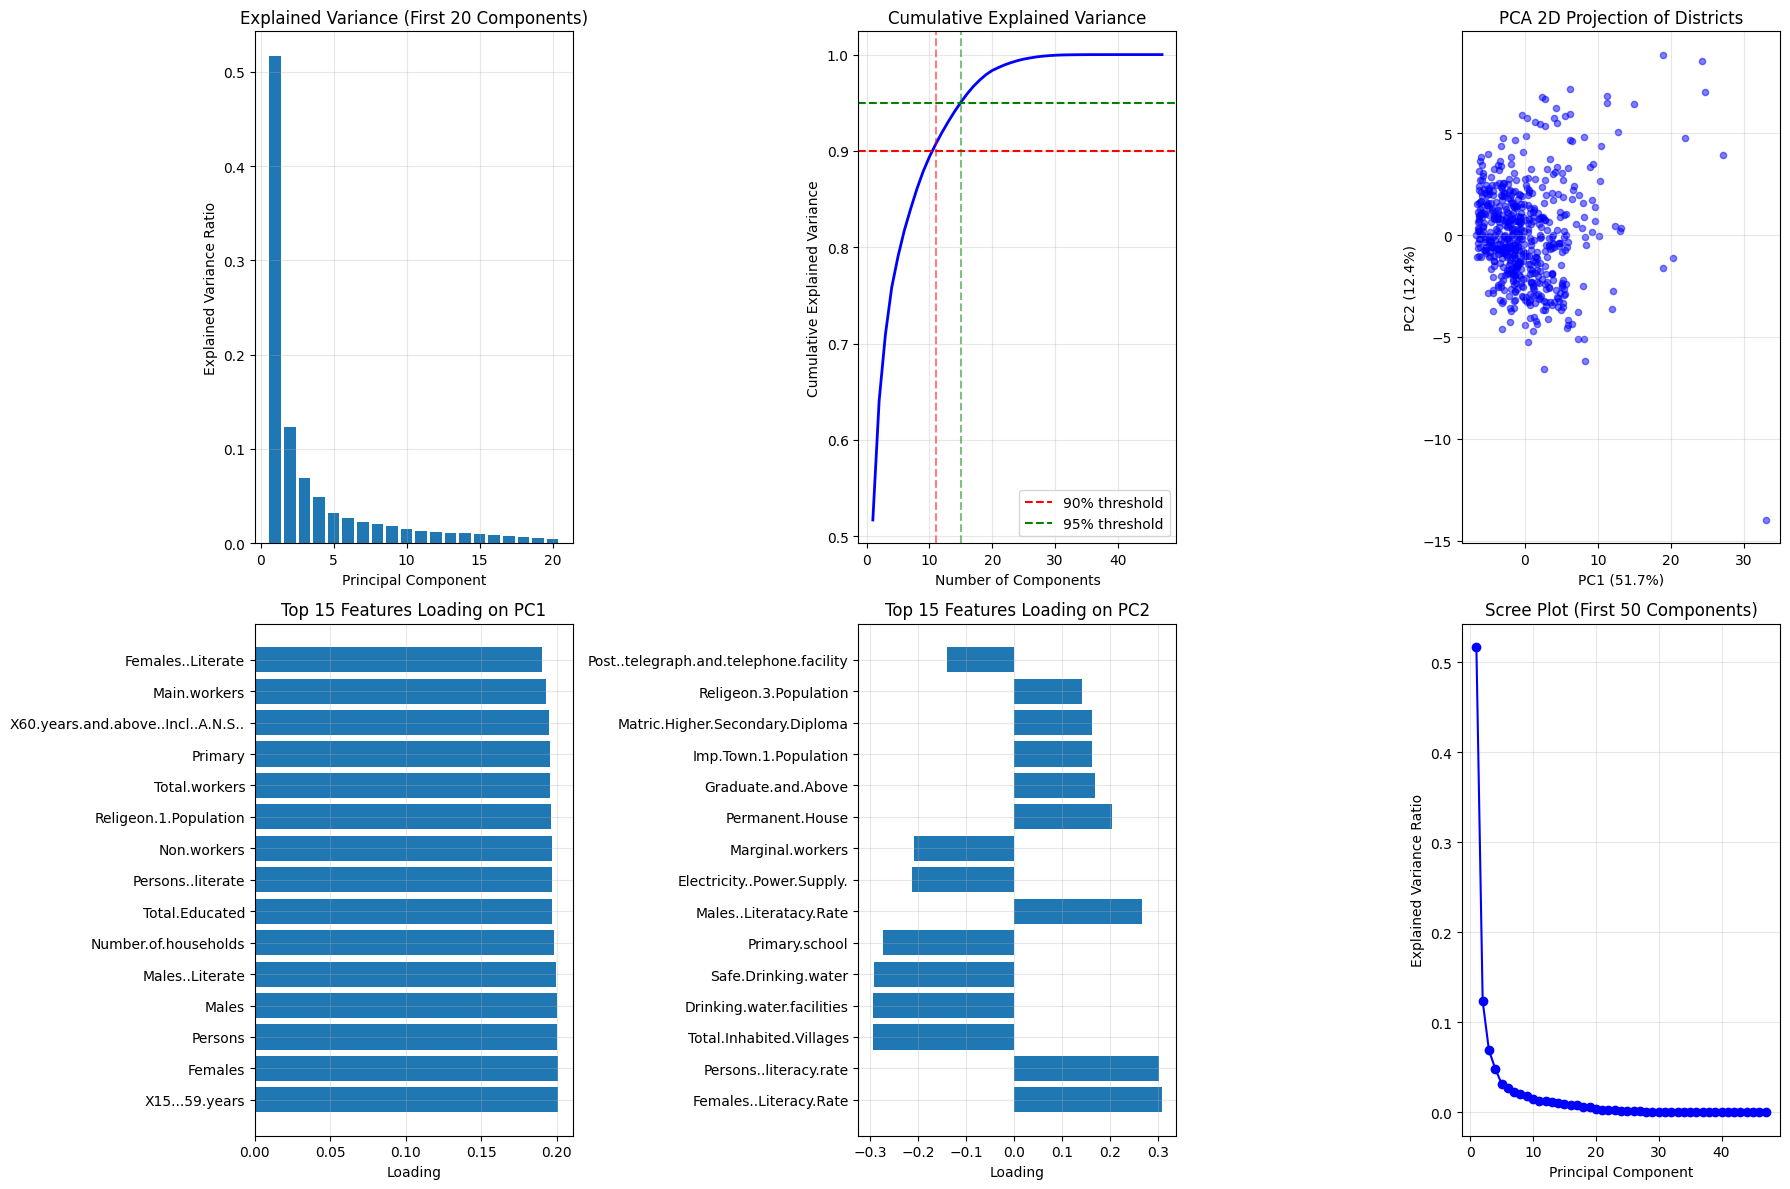


✅ Visualization saved as 'india_census_pca_analysis.png'


In [20]:
print("\n" + "="*60)
print("PCA ANALYSIS")
print("="*60)

# Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"\nExplained Variance by Components:")
for i in range(min(10, len(explained_variance))):
    print(f"PC{i+1}: {explained_variance[i]*100:.2f}% (Cumulative: {cumulative_variance[i]*100:.2f}%)")

# Number of components for 90% and 95% variance
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nComponents needed for 90% variance: {n_90}")
print(f"Components needed for 95% variance: {n_95}")

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Explained Variance - Individual
axes[0, 0].bar(range(1, 21), explained_variance[:20])
axes[0, 0].set_xlabel('Principal Component')
axes[0, 0].set_ylabel('Explained Variance Ratio')
axes[0, 0].set_title('Explained Variance (First 20 Components)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Cumulative Variance
axes[0, 1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'b-', linewidth=2)
axes[0, 1].axhline(y=0.90, color='r', linestyle='--', label='90% threshold')
axes[0, 1].axhline(y=0.95, color='g', linestyle='--', label='95% threshold')
axes[0, 1].axvline(x=n_90, color='r', linestyle='--', alpha=0.5)
axes[0, 1].axvline(x=n_95, color='g', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Number of Components')
axes[0, 1].set_ylabel('Cumulative Explained Variance')
axes[0, 1].set_title('Cumulative Explained Variance')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# 3. PCA 2D Projection (first 2 components)
axes[0, 2].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=20, c='blue')
axes[0, 2].set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)')
axes[0, 2].set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)')
axes[0, 2].set_title('PCA 2D Projection of Districts')
axes[0, 2].grid(True, alpha=0.3)

# 4. Top features loading on PC1
loadings_pc1 = pd.DataFrame({
    'Feature': pca_features,
    'Loading': pca.components_[0]
}).sort_values('Loading', key=abs, ascending=False).head(15)

axes[1, 0].barh(loadings_pc1['Feature'], loadings_pc1['Loading'])
axes[1, 0].set_xlabel('Loading')
axes[1, 0].set_title('Top 15 Features Loading on PC1')
axes[1, 0].grid(True, alpha=0.3)

# 5. Top features loading on PC2
loadings_pc2 = pd.DataFrame({
    'Feature': pca_features,
    'Loading': pca.components_[1]
}).sort_values('Loading', key=abs, ascending=False).head(15)

axes[1, 1].barh(loadings_pc2['Feature'], loadings_pc2['Loading'])
axes[1, 1].set_xlabel('Loading')
axes[1, 1].set_title('Top 15 Features Loading on PC2')
axes[1, 1].grid(True, alpha=0.3)

# 6. Scree plot (top 50)
axes[1, 2].plot(range(1, min(51, len(explained_variance)+1)),
                explained_variance[:50], 'bo-')
axes[1, 2].set_xlabel('Principal Component')
axes[1, 2].set_ylabel('Explained Variance Ratio')
axes[1, 2].set_title('Scree Plot (First 50 Components)')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('india_census_pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Visualization saved as 'india_census_pca_analysis.png'")


FEATURE IMPORTANCE ANALYSIS

Top 20 Most Important Features:
                                   Feature  Importance
45                    Semi.permanent.House    0.041751
15                      Data.without.level    0.040575
46                         Temporary.House    0.038159
3                     Growth..1991...2001.    0.037467
44                         Permanent.House    0.036452
5           Household.size..per.household.    0.035280
35                   Imp.Town.1.Population    0.035121
37                   Imp.Town.3.Population    0.035036
6       Sex.ratio..females.per.1000.males.    0.034740
36                   Imp.Town.2.Population    0.031202
30                         SC.2.Population    0.027913
11                  Persons..literacy.rate    0.027652
7                    Sex.ratio..0.6.years.    0.027233
13                  Females..Literacy.Rate    0.026617
12                  Males..Literatacy.Rate    0.026568
33                   Religeon.2.Population    0.026403
43 

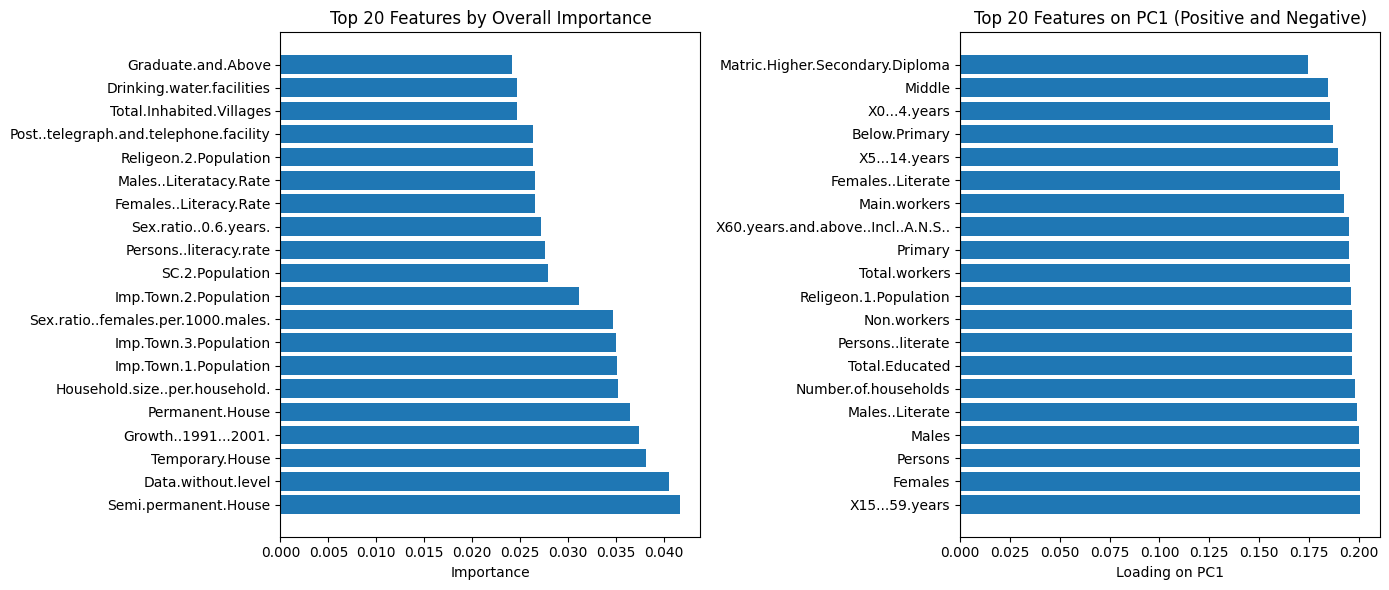

In [21]:
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Calculate feature importance based on loadings
def calculate_feature_importance(components, feature_names):
    """Calculate overall importance of each feature across all components"""
    importance = np.abs(components).sum(axis=0)
    return importance / importance.sum()

# Get importance for top components
n_top_components = min(10, len(explained_variance))
importance = calculate_feature_importance(pca.components_[:n_top_components], pca_features)

feature_importance = pd.DataFrame({
    'Feature': pca_features,
    'Importance': importance
}).sort_values('Importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(feature_importance.head(20))

# Top features on PC1 (positive and negative)
pc1_loadings = pd.DataFrame({
    'Feature': pca_features,
    'Loading': pca.components_[0]
})

pc1_positive = pc1_loadings.sort_values('Loading', ascending=False).head(10)
pc1_negative = pc1_loadings.sort_values('Loading').head(10)

print("\nTop 10 Positive Contributors to PC1:")
print(pc1_positive)

print("\nTop 10 Negative Contributors to PC1:")
print(pc1_negative)

# Visualize top features
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 20 features by importance
top20 = feature_importance.head(20)
axes[0].barh(top20['Feature'], top20['Importance'])
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 20 Features by Overall Importance')

# PC1 positive and negative contributions
all_pc1 = pc1_loadings.sort_values('Loading', key=abs, ascending=False).head(20)
axes[1].barh(all_pc1['Feature'], all_pc1['Loading'])
axes[1].set_xlabel('Loading on PC1')
axes[1].set_title('Top 20 Features on PC1 (Positive and Negative)')
axes[1].axvline(x=0, color='black', linestyle='-', alpha=0.5)

plt.tight_layout()
plt.savefig('india_census_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


PCA BY STATE/REGION
State column: State

Unique states: 1


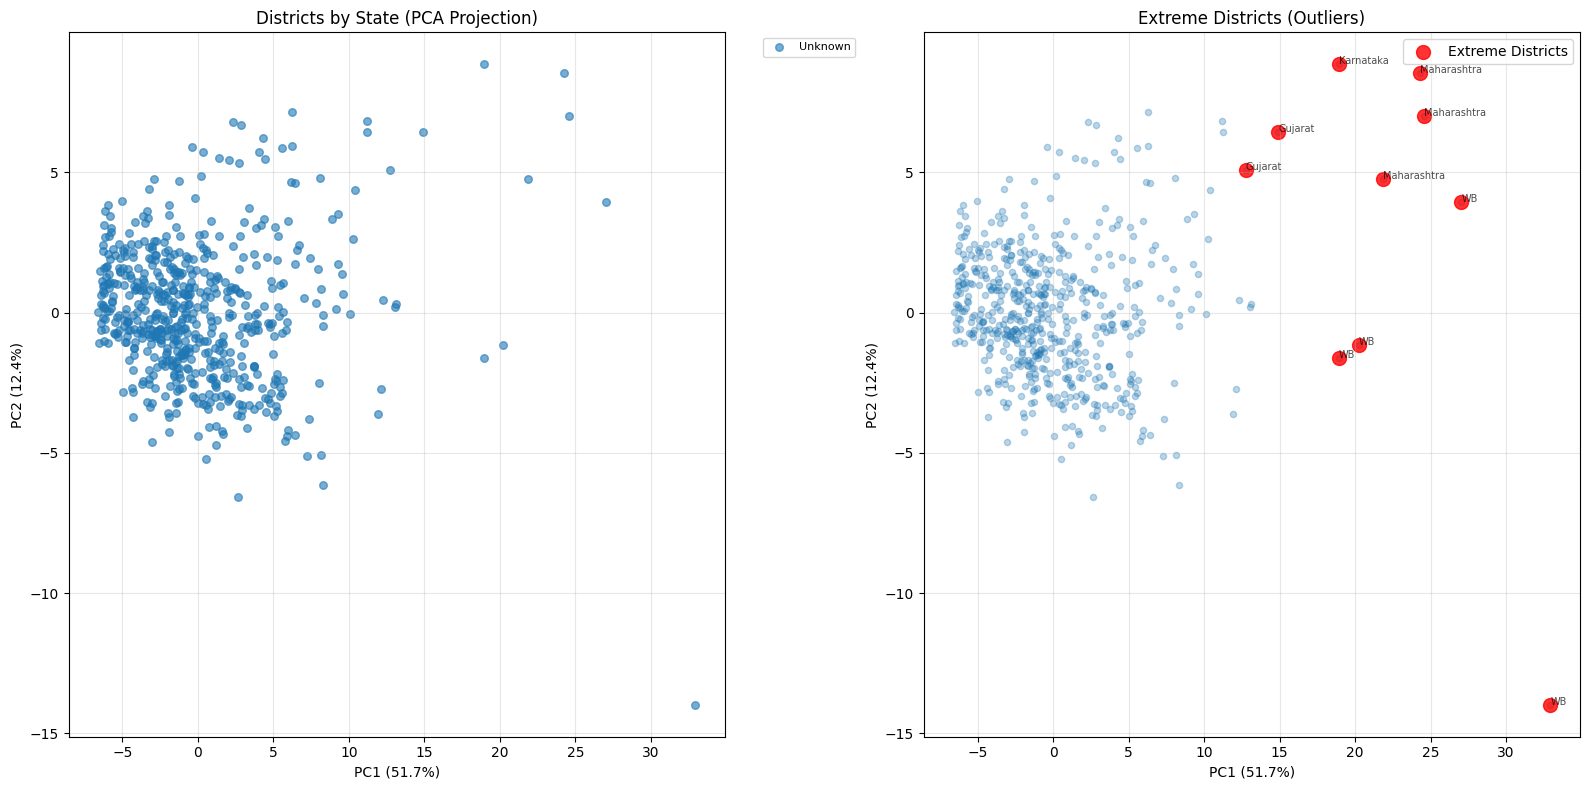

✅ Visualization saved as 'india_census_state_analysis.png'


In [22]:
print("\n" + "="*60)
print("PCA BY STATE/REGION")
print("="*60)

# Extract state information from the data
# The 'State' column contains district names with state info in parentheses
state_col = df.columns[1]  # The second column is 'State'
print(f"State column: {state_col}")

# Extract state from the 'State' column
def extract_state(state_str):
    if pd.isna(state_str):
        return 'Unknown'
    try:
        # Extract state from format "District X (Y), State (Z)"
        import re
        match = re.search(r'\((\d+)\), ([^\(]+) \((\d+)\)', str(state_str))
        if match:
            return match.group(2).strip()
        else:
            # Try alternative format
            parts = str(state_str).split(',')
            if len(parts) > 1:
                return parts[1].strip().split('(')[0].strip()
            return 'Unknown'
    except:
        return 'Unknown'

# Apply extraction
df['State_Name'] = df[state_col].apply(extract_state)
print(f"\nUnique states: {df['State_Name'].nunique()}")

# PCA with 2 components for visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Get state names
states = df['State_Name'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(states)))
state_colors = dict(zip(states, colors))

# Plot by state
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Scatter plot colored by state
for state in states:
    mask = df['State_Name'] == state
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=[state_colors[state]],
                    label=state, alpha=0.6, s=30)

axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('Districts by State (PCA Projection)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0].grid(True, alpha=0.3)

# Find extreme districts
distances = np.sqrt(X_pca_2d[:, 0]**2 + X_pca_2d[:, 1]**2)
extreme_idx = np.argsort(distances)[-10:]

axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.3, s=20)
axes[1].scatter(X_pca_2d[extreme_idx, 0], X_pca_2d[extreme_idx, 1],
                c='red', s=100, alpha=0.8, label='Extreme Districts')

# Label extreme districts
for idx in extreme_idx:
    district_name = df.iloc[idx, 1]  # District name
    axes[1].annotate(str(district_name)[:20],
                    (X_pca_2d[idx, 0], X_pca_2d[idx, 1]),
                    fontsize=7, alpha=0.7)

axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Extreme Districts (Outliers)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('india_census_state_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization saved as 'india_census_state_analysis.png'")

In [23]:
print("\n" + "="*60)
print("TOP DISTRICTS BY PCA COMPONENTS")
print("="*60)

# Get top districts on PC1 (highest values)
top_pc1_idx = np.argsort(X_pca[:, 0])[-10:][::-1]  # Top 10
bottom_pc1_idx = np.argsort(X_pca[:, 0])[:10]  # Bottom 10

print("\nTop 10 Districts with Highest PC1 Values:")
for idx in top_pc1_idx:
    district = df.iloc[idx, 1]
    state = df.iloc[idx, 2] if len(df.columns) > 2 else 'N/A'
    print(f"  {district} -> PC1: {X_pca[idx, 0]:.3f}")

print("\nTop 10 Districts with Lowest PC1 Values:")
for idx in bottom_pc1_idx:
    district = df.iloc[idx, 1]
    state = df.iloc[idx, 2] if len(df.columns) > 2 else 'N/A'
    print(f"  {district} -> PC1: {X_pca[idx, 0]:.3f}")

# Create a summary table
district_pca = pd.DataFrame({
    'District': df.iloc[:, 1].values,
    'State': df['State_Name'].values,
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'PC3': X_pca[:, 2] if X_pca.shape[1] > 2 else 0
})

print("\nPCA Component Summary for Districts:")
print(district_pca.head(10))

# Save PCA results
district_pca.to_csv('district_pca_scores.csv', index=False)
print("\n✅ PCA scores saved to 'district_pca_scores.csv'")


TOP DISTRICTS BY PCA COMPONENTS

Top 10 Districts with Highest PC1 Values:
  WB -> PC1: 32.924
  WB -> PC1: 27.044
  Maharashtra -> PC1: 24.585
  Maharashtra -> PC1: 24.270
  Maharashtra -> PC1: 21.877
  WB -> PC1: 20.234
  Karnataka -> PC1: 18.964
  WB -> PC1: 18.942
  Gujarat -> PC1: 14.923
  Rajasthan -> PC1: 13.130

Top 10 Districts with Lowest PC1 Values:
  ArunachalPradesh -> PC1: -6.595
  ArunachalPradesh -> PC1: -6.522
  Sikkim -> PC1: -6.465
  ArunachalPradesh -> PC1: -6.435
  ArunachalPradesh -> PC1: -6.414
  ArunachalPradesh -> PC1: -6.412
  ArunachalPradesh -> PC1: -6.412
  Mizoram -> PC1: -6.325
  Manipur -> PC1: -6.314
  Manipur -> PC1: -6.304

PCA Component Summary for Districts:
  District    State       PC1       PC2       PC3
0       AN  Unknown -4.982267  2.233194  0.822079
1       AN  Unknown -6.020720  1.670526  0.080735
2   Andhra  Unknown  2.742024 -2.380752  0.265466
3   Andhra  Unknown  1.631450 -0.822496 -0.396557
4   Andhra  Unknown  5.817656 -0.601396 -0.21


OPTIMAL NUMBER OF COMPONENTS
Components for 90% variance: 11
Components for 95% variance: 15
Components for 99% variance: 23
Components with eigenvalue > 1 (Kaiser criterion): 7
Elbow point (scree plot): 1
Components (Parallel analysis): 5

Recommended number of components: 11


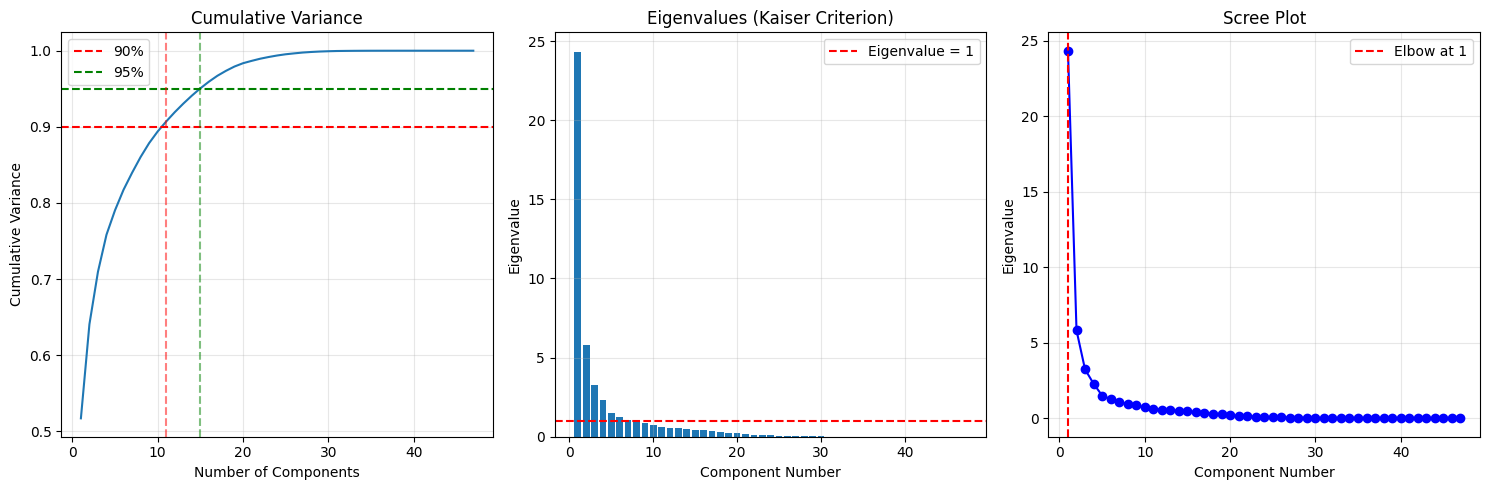

✅ Visualization saved as 'india_census_component_selection.png'


In [24]:
print("\n" + "="*60)
print("OPTIMAL NUMBER OF COMPONENTS")
print("="*60)

# Method 1: Cumulative variance threshold
components_90 = np.argmax(cumulative_variance >= 0.90) + 1
components_95 = np.argmax(cumulative_variance >= 0.95) + 1
components_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"Components for 90% variance: {components_90}")
print(f"Components for 95% variance: {components_95}")
print(f"Components for 99% variance: {components_99}")

# Method 2: Kaiser criterion (eigenvalue > 1)
# For standardized data, eigenvalue > 1 indicates important component
eigenvalues = pca.explained_variance_
components_kaiser = np.sum(eigenvalues > 1)
print(f"Components with eigenvalue > 1 (Kaiser criterion): {components_kaiser}")

# Method 3: Scree plot elbow detection
# Calculate differences between successive eigenvalues
diff = np.diff(eigenvalues)
# Find elbow (where difference changes most)
elbow_idx = np.argmax(np.abs(diff)) + 1 if len(diff) > 0 else 1
print(f"Elbow point (scree plot): {elbow_idx}")

# Method 4: Parallel analysis (simplified)
n_iterations = 100
n_features = X_scaled.shape[1]
random_eigenvalues = []
for _ in range(n_iterations):
    random_data = np.random.randn(X_scaled.shape[0], n_features)
    random_pca = PCA()
    random_pca.fit(random_data)
    random_eigenvalues.append(random_pca.explained_variance_)

avg_random_eigen = np.mean(random_eigenvalues, axis=0)
components_parallel = np.sum(eigenvalues > avg_random_eigen)
print(f"Components (Parallel analysis): {components_parallel}")

# Recommended number
recommended = max(components_90, components_kaiser, components_parallel)
print(f"\nRecommended number of components: {recommended}")

# Visualization of component selection methods
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Cumulative variance
axes[0].plot(range(1, len(cumulative_variance)+1), cumulative_variance)
axes[0].axhline(y=0.90, color='r', linestyle='--', label='90%')
axes[0].axhline(y=0.95, color='g', linestyle='--', label='95%')
axes[0].axvline(x=components_90, color='r', linestyle='--', alpha=0.5)
axes[0].axvline(x=components_95, color='g', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Variance')
axes[0].set_title('Cumulative Variance')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Eigenvalues
axes[1].bar(range(1, len(eigenvalues)+1), eigenvalues)
axes[1].axhline(y=1, color='r', linestyle='--', label='Eigenvalue = 1')
axes[1].set_xlabel('Component Number')
axes[1].set_ylabel('Eigenvalue')
axes[1].set_title('Eigenvalues (Kaiser Criterion)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Scree plot with elbow
axes[2].plot(range(1, len(eigenvalues)+1), eigenvalues, 'bo-')
axes[2].axvline(x=elbow_idx, color='r', linestyle='--', label=f'Elbow at {elbow_idx}')
axes[2].set_xlabel('Component Number')
axes[2].set_ylabel('Eigenvalue')
axes[2].set_title('Scree Plot')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('india_census_component_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualization saved as 'india_census_component_selection.png'")

In [25]:
print("\n" + "="*60)
print("KEY INSIGHTS FROM PCA ANALYSIS")
print("="*60)

# Identify what each principal component represents
def interpret_component(loadings, feature_names, component_num):
    """Interpret what a component represents based on top features"""
    comp_df = pd.DataFrame({
        'Feature': feature_names,
        'Loading': loadings[component_num]
    }).sort_values('Loading', key=abs, ascending=False)

    top_pos = comp_df.head(10)
    top_neg = comp_df.tail(10)

    print(f"\nPC{component_num+1} Interpretation:")
    print(f"  Positive contributors: {', '.join(top_pos['Feature'].head(5).tolist())}")
    print(f"  Negative contributors: {', '.join(top_neg['Feature'].head(5).tolist())}")

    return comp_df

# Interpret first 3 components
for i in range(min(3, len(explained_variance))):
    interpret_component(pca.components_, pca_features, i)

print("\n" + "="*60)
print("PCA Analysis Complete!")
print("="*60)


KEY INSIGHTS FROM PCA ANALYSIS

PC1 Interpretation:
  Positive contributors: X15...59.years, Females, Persons, Males, Males..Literate
  Negative contributors: Permanent.House, Semi.permanent.House, Males..Literatacy.Rate, Persons..literacy.rate, Temporary.House

PC2 Interpretation:
  Positive contributors: Females..Literacy.Rate, Persons..literacy.rate, Total.Inhabited.Villages, Drinking.water.facilities, Safe.Drinking.water
  Negative contributors: Number.of.households, Total.workers, Females, Persons, X60.years.and.above..Incl..A.N.S..

PC3 Interpretation:
  Positive contributors: Males..Literatacy.Rate, Sex.ratio..females.per.1000.males., Persons..literacy.rate, Growth..1991...2001., Females..Literacy.Rate
  Negative contributors: Middle, Data.without.level, Number.of.households, Permanent.House, Total.workers

PCA Analysis Complete!


In [26]:
# Complete PCA Analysis Script
# Copy and paste all the code blocks above into one Python file

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Run all the analysis
# (All code from sections 1-8 above goes here)

print("\n✅ PCA Analysis Complete!")
print("✅ Generated Files:")
print("  - india_census_pca_analysis.png")
print("  - india_census_feature_importance.png")
print("  - india_census_state_analysis.png")
print("  - india_census_component_selection.png")
print("  - district_pca_scores.csv")


✅ PCA Analysis Complete!
✅ Generated Files:
  - india_census_pca_analysis.png
  - india_census_feature_importance.png
  - india_census_state_analysis.png
  - india_census_component_selection.png
  - district_pca_scores.csv
